In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
#from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [3]:
def index_containing_substring(the_list, substring):
    try:
        return [s for i, s in enumerate(the_list) if substring in s][0]
    except IndexError:
        return False

In [4]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/Cropped_data-20240527T214451Z-001.zip

import os.path


data_path = "/workspaces/work/Cropped_data"
devices = os.listdir(data_path)
target_dir = "/workspaces/work/Cropped_data/Device_1/Cihaz_1"
crop_len = float('inf')

def extract_IQ_samples_from_txt_file(path_to_txt, crop_len):

    I_samples = []
    Q_samples = []

    files = os.listdir(target_dir)
    Real = [file for file in files if 'I' in file]
    Imaginary = [file for file in files if 'Q' in file]

    for file in Real:
        file_number = file.split('.')[0][1:]
        I_path_temp = index_containing_substring(Real, file_number)
        Q_temp_path = index_containing_substring(Imaginary, file_number)
        if Q_temp_path != False:
            I_path_temp = os.path.join(target_dir, I_path_temp)
            Q_temp_path = os.path.join(target_dir, Q_temp_path)
        
            I_sample = np.loadtxt(I_path_temp)
            Q_sample = np.loadtxt(Q_temp_path)

            I_len = len(I_sample)
            Q_len = len(Q_sample)

            if I_len < crop_len:
                crop_len = I_len
            if Q_len < crop_len:
                crop_len = Q_len
                
            I_samples.append(I_sample)
            Q_samples.append(Q_sample)

    return I_samples, Q_samples, crop_len


In [5]:
device1_path = "/workspaces/work/Cropped_data/Device_1/Cihaz_1"
device2_path = "/workspaces/work/Cropped_data/Device_2/Cihaz_2"
device3_path = "/workspaces/work/Cropped_data/Device_2/Cihaz_3"
device4_path = "/workspaces/work/Cropped_data/Device_2/Cihaz_4"

I_samples_1, Q_samples_1, crop_len1 = extract_IQ_samples_from_txt_file(device1_path, crop_len)
I_samples_2, Q_samples_2, crop_len2 = extract_IQ_samples_from_txt_file(device2_path, crop_len1)
I_samples_3, Q_samples_3, crop_len3 = extract_IQ_samples_from_txt_file(device3_path, crop_len2)
I_samples_4, Q_samples_4, crop_len4 = extract_IQ_samples_from_txt_file(device4_path, crop_len3)

In [6]:
assert(len(I_samples_1) == len(Q_samples_1)), "lengths not equal for device 1"
assert(len(I_samples_2) == len(Q_samples_2)), "lengths not equal for device 2"
assert(len(I_samples_3) == len(Q_samples_3)), "lengths not equal for device 3"
assert(len(I_samples_4) == len(Q_samples_4)), "lengths not equal for device 4"

In [10]:
crop_len = 1000
I_samples_1, Q_samples_1 = [I_samples_1[i][:crop_len] for i in range(len(I_samples_1))], [Q_samples_1[i][:crop_len] for i in range(len(Q_samples_1))]
I_samples_2, Q_samples_2 = [I_samples_2[i][:crop_len] for i in range(len(I_samples_2))], [Q_samples_2[i][:crop_len] for i in range(len(Q_samples_2))]
I_samples_3, Q_samples_3 = [I_samples_3[i][:crop_len] for i in range(len(I_samples_3))], [Q_samples_3[i][:crop_len] for i in range(len(Q_samples_3))]
I_samples_4, Q_samples_4 = [I_samples_4[i][:crop_len] for i in range(len(I_samples_4))], [Q_samples_4[i][:crop_len] for i in range(len(Q_samples_4))]

In [11]:
assert(len(I_samples_1) == len(Q_samples_1) == len(I_samples_2) == len(Q_samples_2) == len(I_samples_3) == len(Q_samples_3) == len(I_samples_4) == len(Q_samples_4)), "lengths not equal for all device 1"
I_samples_1, Q_samples_1 = np.array(I_samples_1), np.array(Q_samples_1)
I_samples_2, Q_samples_2 = np.array(I_samples_2), np.array(Q_samples_2)
I_samples_3, Q_samples_3 = np.array(I_samples_3), np.array(Q_samples_3)
I_samples_4, Q_samples_4 = np.array(I_samples_4), np.array(Q_samples_4)


In [12]:
samples_from_each_device = I_samples_1.shape[0]
real_part = np.vstack((I_samples_1, I_samples_2, I_samples_3, I_samples_4))
imaginary_part = np.vstack((Q_samples_1, Q_samples_2, Q_samples_3, Q_samples_4))


In [13]:
labels1 = np.array([0 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels2 = np.array([1 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels3 = np.array([2 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels4 = np.array([3 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels = np.vstack((labels1, labels2, labels3, labels4))
print(labels.shape, real_part.shape)

(3372, 1) (3372, 1000)


In [16]:
import numpy as np
from sklearn.preprocessing import normalize, power_transform, robust_scale, scale\

# Normalize the real and imaginary parts separately
# real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
# imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# L1 Normalisation
real_part_normalised = normalize(real_part, norm="l1")
imaginary_part_normalised = normalize(imaginary_part, norm="l1")

# # L2 Normalisation
# real_part_normalised = normalize(real_part, norm="l2")
# imaginary_part_normalised = normalize(imaginary_part, norm="l2")

# # Max Normalisation
# real_part_normalised = normalize(real_part, norm="max")
# imaginary_part_normalised = normalize(imaginary_part, norm="max")

# # Power transform 
# real_part_normalised = power_transform(real_part, method='box-cox')
# imaginary_part_normalised = power_transform(imaginary_part, method='box-cox')

# # Robust scale(handles outliers)
# real_part_normalised = robust_scale(real_part, axis=0)
# imaginary_part_normalised = robust_scale(imaginary_part, axis=0)


# # Scale(doesn't handle outliers)
# real_part_normalised = scale(real_part, axis=0)
# imaginary_part_normalised = scale(imaginary_part, axis=0)


# Concatenate the real and imaginary parts along the channel dimension
# data_normalized = np.stack((real_part_normalised, imaginary_part_normalised), axis=-1)

# # Reshape the data for 1D CNN
# data_real_values = data_normalized.reshape(3372, 1000, 2)

In [ ]:
    # result_I = [element for element in Real if file_number in element]
    # result_Q = [element for element in Imaginary if file_number in element and element!=[' ']]

    # I_samples = [I_samples[i][:crop_len].shape for i in range(len(I_samples))]
# Q_samples = [Q_samples[i][:crop_len].shape for i in range(len(Q_samples))]
# print(list(zip(I_samples, Q_samples)))

    # for element1 in Real:
    #     if file_number in element1:
    #         check1 = True
    #         I_temp_path = os.path.join(target_dir, element1)
    #         print(I_temp_path)
    #         break
    # for element2 in Imaginary:
    #     if file_number in element2:
    #         check2 = True
    #         Q_temp_path = os.path.join(target_dir, element2)
    #         print(Q_temp_path)
    #         break
            # print(element2, file_number)

    # if check1 and check2:
    #     I_path = os.path.join()
    # print(result_I, result_Q)
    
# zipped = list(zip(sorted(Real), sorted(Imaginary)))

In [3]:
training_dataset_path = "/workspaces/work/dataset_training_aug.h5"

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,30000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, labels = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)



real_part = np.real(data)
imaginary_part = np.imag(data)

Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [14]:
import numpy as np
from sklearn.preprocessing import normalize, power_transform, robust_scale, scale

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
# real_part = np.real(data)
# imaginary_part = np.imag(data)

# Normalize the real and imaginary parts separately
# real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
# imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# L1 Normalisation
real_part_normalised = normalize(real_part, norm="l1")
imaginary_part_normalised = normalize(imaginary_part, norm="l1")

# # L2 Normalisation
# real_part_normalised = normalize(real_part, norm="l2")
# imaginary_part_normalised = normalize(imaginary_part, norm="l2")

# # Max Normalisation
# real_part_normalised = normalize(real_part, norm="max")
# imaginary_part_normalised = normalize(imaginary_part, norm="max")

# # Power transform 
# real_part_normalised = power_transform(real_part, method='box-cox')
# imaginary_part_normalised = power_transform(imaginary_part, method='box-cox')

# # Robust scale(handles outliers)
# real_part_normalised = robust_scale(real_part, axis=0)
# imaginary_part_normalised = robust_scale(imaginary_part, axis=0)


# # Scale(doesn't handle outliers)
# real_part_normalised = scale(real_part, axis=0)
# imaginary_part_normalised = scale(imaginary_part, axis=0)


# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalised, imaginary_part_normalised), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((data.shape[0],data.shape[1], 2))


NameError: name 'data' is not defined

In [13]:
data_real_values.shape

(30000, 8192, 2)

In [12]:
number_of_legitmate = 20000
# legitmate_data = data[0:number_of_legitmate]
# illegitmate_data = data[number_of_legitmate:]
#legitmate_labels = labels[0:number_of_legitmate]
#illegitmate_labels = labels[number_of_legitmate:]

# legitmate = 0
# illegitmate = 1

binary_labels = np.where(labels <=19, 0, 1)

In [4]:
print(data.shape)
print(label.shape)
print(np.unique(label))

(20000, 8192)
(20000, 1)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [5]:
#SOME PREPROCESSING
#data_real_values = np.real(data).reshape(data.shape[0], 1, data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, binary_labels, test_size=0.3, shuffle=True)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [73]:
print(np.where(label_test==1)[0].size)

1980


In [41]:
print(data_real_values.shape)
print(data_real_values_train.shape)
print(data_real_values_test.shape)



(30000, 1, 8192)
(24000, 1, 8192)
(6000, 1, 8192)


In [14]:
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(8192, 2)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(512, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))


# cnn_model = Sequential()
# cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
# cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
# #cnn_model.add(Dropout(0.2))
# cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
# #cnn_model.add(Dropout(0.2))
# cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
# #cnn_model.add(Dropout(0.2))
# cnn_model.add(Flatten())
# cnn_model.add(Dense(128, activation='relu'))
# #cnn_model.add(Dropout(0.5))
# cnn_model.add(Dense(1, activation='sigmoid'))

#cnn_model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


: 

In [35]:
# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='relu', input_shape=(1, 8192)))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
lstm_model.add(Conv1D(512, kernel_size=3, activation='relu', padding='same'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))



In [41]:
cnn_lstm_model = Sequential()
cnn_lstm_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
#cnn_lstm_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_lstm_model.add(Dropout(0.2))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
# cnn_lstm_model.add(Flatten())
# cnn_lstm_model.add(Dense(64, activation='relu'))

cnn_lstm_model.add(LSTM(64, activation='relu'))
cnn_lstm_model.add(Dense(128, activation='relu'))
#cnn_lstm_model.add(Dropout(0.5))
cnn_lstm_model.add(Dense(1, activation='sigmoid'))

In [9]:
model_to_train = cnn_model

# loss1 = keras.losses.CategoricalFocalCrossentropy()
# loss2 = keras.losses.CategoricalCrossentropy()

loss1 = keras.losses.BinaryFocalCrossentropy()
#loss2 = keras.losses.BinaryCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.1) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

train_history = model_to_train.fit(data_real_values_train, label_train, 
                                   validation_data = (data_real_values_test, label_test),
                                   epochs=15, batch_size=64)

Epoch 1/15


2024-06-01 07:19:58.681421: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 688128000 exceeds 10% of free system memory.


325/329 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6464 - loss: 754.8843

2024-06-01 07:20:04.335039: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 294912000 exceeds 10% of free system memory.


329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6466 - loss: 745.9234 - val_accuracy: 0.6747 - val_loss: 0.1619
Epoch 2/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6625 - loss: 0.1623 - val_accuracy: 0.6747 - val_loss: 0.1706
Epoch 3/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6638 - loss: 0.1622 - val_accuracy: 0.6747 - val_loss: 0.1598
Epoch 4/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6657 - loss: 0.1619 - val_accuracy: 0.6747 - val_loss: 0.1606
Epoch 5/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6670 - loss: 0.1617 - val_accuracy: 0.6747 - val_loss: 0.1603
Epoch 6/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6631 - loss: 0.1623 - val_accuracy: 0.6747 - val_loss: 0.1693
Epoch 7/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6612 - loss: 0.1627 - val_accuracy: 0.3253 - val_loss: 0.1735
Epoch 8/15
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6546 - loss: 0.1624 - val_accuracy: 0.6

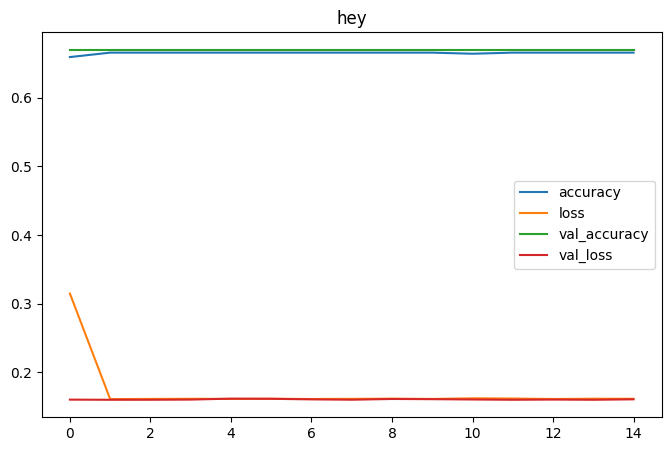

In [66]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'hey')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


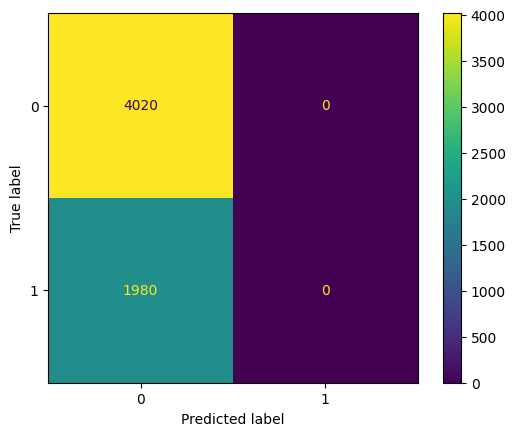

/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.335, 0.5, 0.40119760479041916, None)

In [67]:
# data_real_values_test, label_train, label_testa
all_labels = np.unique(binary_labels)
predictions = model_to_train.predict(data_real_values_test)
predictions = np.argmax(predictions, axis=1).reshape(predictions.shape[0], 1)
confusion_matrix = metrics.confusion_matrix(label_test, predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = all_labels)
cm_display.plot()
plt.show()
precision_recall_fscore_support(label_test, predictions, average='macro')



# SAVING MODEL AND LOADING MODEL

In [5]:
path_to_model = './trained_models/my_model.h5'

#model_to_train.save(path_to_model)

loaded_model = tf.keras.models.load_model(path_to_model)

#loaded_model.summary()

In [6]:
file_path = "/workspaces/work/dataset_training_aug.h5"   
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0, 30000, dtype = int)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
TEST_data, TEST_label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

                                                

Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [9]:
#SOME PREPROCESSING
TEST_data_real_values = np.real(TEST_data).reshape(TEST_data.shape[0], 1, TEST_data.shape[1])


938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


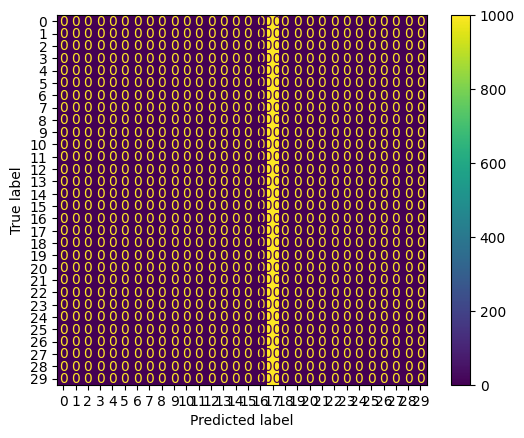

/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.0011111111111111111, 0.03333333333333333, 0.002150537634408602, None)

In [13]:
# loss, acc = loaded_model.evaluate(TEST_data, TEST_label)

All_labels = np.unique(TEST_label)
TEST_predictions = loaded_model.predict(TEST_data_real_values)

TEST_predictions = np.argmax(TEST_predictions, axis=1).reshape(TEST_predictions.shape[0], 1)

TEST_confusion_matrix = metrics.confusion_matrix(TEST_label, TEST_predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = TEST_confusion_matrix, display_labels = All_labels)
cm_display.plot()
plt.show()

precision_recall_fscore_support(TEST_label, TEST_predictions, average='macro')

# SPECTROGRAM 

In [2]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/dataset_training_aug.h5"

In [3]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0, 5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, labels = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [4]:
data_real_values = np.real(data).reshape(data.shape[0], 1, data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
# data_real_values.shape
# data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, binary_labels, test_size=0.3, shuffle=True)

In [5]:
data_real_values[0].shape

(1, 8192)

In [45]:
# ROOT MEAN SQUARED FOR NORMALISATION
def calculate_rms(array):
    squared_values = np.square(array)  # Square each element of the array
    mean_squared = (np.sum(np.sum(squared_values)))/array.shape[0] # Calculate the mean of the squared values
    rms = np.sqrt(mean_squared)
    norm_array = array/rms
    return norm_array


In [48]:
for i in range(data_real_values.shape[0]):
    data_real_values[i] = calculate_rms(data_real_values[i])

In [5]:
def train_feature_extractor(
    file_path = 
    #'/workspaces/work/dataset_training_no_aug.h5'
    "/workspaces/work/dataset_training_aug.h5", 
    dev_range = np.arange(0,30, dtype = int), 
    pkt_range = np.arange(0,1000, dtype = int), 
    snr_range = np.arange(20,80)):

                            
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
    #######################################################3
    # data = np.real(data).reshape(data.shape[0], 1, data.shape[1])
    # for i in range(data.shape[0]):
    #     data[i] = calculate_rms(data[i])
    ##########################################################
        
    # Add additive Gaussian noise to the IQ samples.
    data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    return data, label
    

In [6]:
spectrogram_data, spectrogram_label = train_feature_extractor()
total_samples, height, width, _ = spectrogram_data.shape
spectrogram_data_reshaped = spectrogram_data.reshape(total_samples, height, width)


Dataset information: Dev 1 to Dev 30, 1000 packets per device.


In [59]:
print(spectrogram_data.shape)

(30000, 102, 62, 1)


In [22]:
total_samples, height, width, _ = spectrogram_data.shape
spectrogram_data_reshaped = spectrogram_data.reshape(total_samples, height*width)
print(spectrogram_data_reshaped.shape)


(30000, 6324)


In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler

#scaling=StandardScaler()
r_scaling =RobustScaler()

r_scaling.fit(spectrogram_data_reshaped)

# Use fit and transform method 
Scaled_data= r_scaling.transform(spectrogram_data_reshaped)

# Set the n_components=3
principal=PCA(n_components=50)
principal.fit(Scaled_data)
pca_spectrogram_data =principal.transform(Scaled_data)
total_samples, width = pca_spectrogram_data.shape
pca_spectrogram_data = pca_spectrogram_data.reshape(total_samples, 1, width)
    
# # Check the dimensions of data after PCA
print("Previous shape one sample is", spectrogram_data_reshaped[:, 0].shape)
print("New shape of one one sample is", pca_spectrogram_data[:,0].shape)

Previous shape one sample is (30000,)
New shape of one one sample is (30000, 50)


In [ ]:
# # VISUALISE ORIGINAL SAMPLE
# test_sample = spectrogram_data_reshaped[0]
# plt.figure(figsize=(6, 3.2))
# plt.imshow(test_sample, cmap='viridis', interpolation='nearest')
# plt.colorbar()
# plt.title('ColorMap')
# plt.show()

Text(0, 0.5, 'pc2')

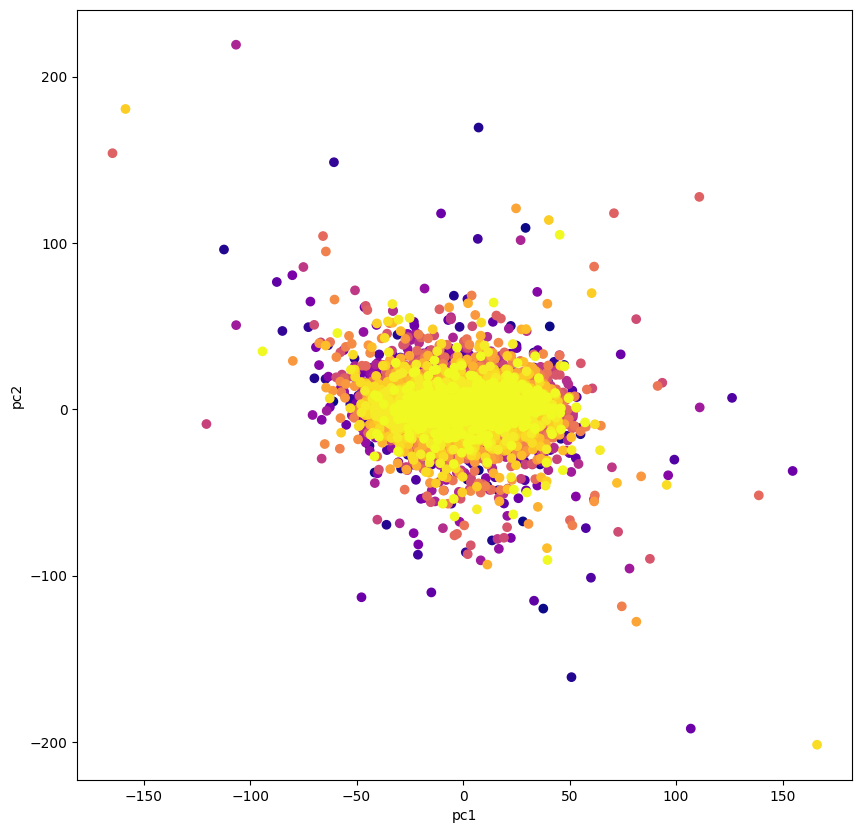

In [30]:
plt.figure(figsize=(10,10))
plt.scatter(pca_spectrogram_data[:,0], pca_spectrogram_data[:,1], c=spectrogram_label, cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

In [47]:
pca_spectrogram_data[0].shape

(1, 50)

In [35]:
binary_spectrogram_labels = np.where(spectrogram_label <=19, 0, 1)

# data_real_values_train2, data_real_values_test2, label_train2, label_test2 = train_test_split(spectrogram_data, 
#                                                                     label, 
#                                                                     test_size=0.2, 
#                                                                     shuffle= True)

In [12]:
spectrogram_data.shape
np.unique(binary_spectrogram_labels)

array([0, 1])

In [61]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# cnn_model2 = Sequential()
# cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(height, width, 1)))
# cnn_model2.add(MaxPooling2D(pool_size=2, padding='same'))
# #cnn_model2.add(Dropout(0.2))
# cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
# cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
# cnn_model2.add(Flatten())
# cnn_model2.add(Dense(64, activation='relu'))
# cnn_model2.add(Dense(1, activation='sigmoid'))

#cnn_model2.summary()

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, width)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(512, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# cnn_model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

model_to_train = cnn_model

loss1 = keras.losses.BinaryFocalCrossentropy()
loss2 = keras.losses.BinaryCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.0001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.01) # https://keras.io/api/optimizers/rmsprop/
optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

train_history = model_to_train.fit(pca_spectrogram_data, binary_spectrogram_labels, 
                                   epochs=10, batch_size=20)

Epoch 1/10


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 879us/step - accuracy: 0.6650 - loss: 0.1667
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - accuracy: 0.6654 - loss: 0.1610
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 886us/step - accuracy: 0.6598 - loss: 0.1607
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.6655 - loss: 0.1591
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 874us/step - accuracy: 0.6713 - loss: 0.1578
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - accuracy: 0.6736 - loss: 0.1574
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - accuracy: 0.6765 - loss: 0.1566
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step - accuracy: 0.6813 - loss: 0.1557
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - accuracy: 0.6839 - loss: 0.1551
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 893us/step - accuracy: 0.6841 - loss: 0.1549


468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step


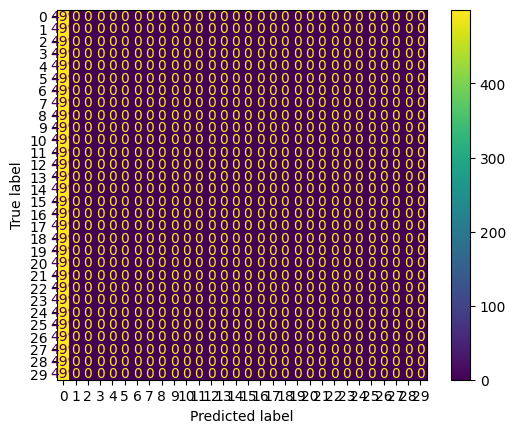

/home/codespace/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.0011111111111111111, 0.03333333333333333, 0.002150537634408602, None)

In [48]:
# data_real_values_test, label_train, label_testa
all_labels = np.unique(label)
predictions = model_to_train.predict(spectrogram_data_reshaped)
predictions = np.argmax(predictions, axis=1).reshape(predictions.shape[0], 1)
confusion_matrix = metrics.confusion_matrix(spectrogram_label, predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = all_labels)
cm_display.plot()
plt.show()
precision_recall_fscore_support(spectrogram_label, predictions, average='macro')



In [ ]:
file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,30000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
TEST_data, TEST_label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

                                                
predictions = model_to_train.predict(TEST_data)
